# Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data

In [ ]:
df = pd.read_csv("/content/House_Price_Data.csv")
df

,Property_ID,Area,Bedrooms,Bathrooms,Square_Feet,Parking,Furnishing_Status,Year_Built,Distance_to_CityCenter,Crime_Rate,Locality_Rating,House_Price
0,1,City Outskirts,3.0,3,1558,No,Unfurnished,NaN,11.40,38.95,NaN,174194
1,2,Industrial Zone,NaN,3,1785,Yes,Unfurnished,NaN,23.88,29.85,NaN,133069
2,3,Riverside,4.0,1,1442,Yes,Semi-Furnished,NaN,14.02,19.76,NaN,204347
3,4,Industrial Zone,3.0,4,1777,Yes,Semi-Furnished,NaN,17.63,55.76,NaN,224295
4,5,Uptown,2.0,2,632,Yes,Furnished,NaN,17.30,38.90,NaN,164406
...,...,...,...,...,...,...,...,...,...,...,...,...
8155,2081,Riverside,1.0,2,1621,Yes,Semi-Furnished,NaN,-12.73,57.14,NaN,124677
8156,6956,Suburb,3.0,3,2013,No,Furnished,2001.0,11.64,44.62,8.0,238917
8157,6488,City Outskirts,3.0,3,2151,Yes,Unfurnished,NaN,11.82,35.39,NaN,188446
8158,648,Suburb,3.0,1,2183,No,Furnished,NaN,8.31,38.61,NaN,252609


# About the Data set

Property_ID -- it is a unique value assigned to different properties

Area -- it tells the area i.e; about he zone at which the house is located

Bedrooms -- No.of bedrooms in the house

Square_Feet -- living area in Square Feet

Parking -- Tells weather parking is available or not

Furnishing_Status -- Tells weather the house has furniture or not or is it semi- furnished

Year_Built -- The year in which the house is biilt

Distance_to_CityCenter -- Distance of the house from the nearest city center

Crime_Rate -- It tells the crime rate of the area at which the house is located

Locality_Rating --  quality of the area where the house is located.

House_Price -- It is the target varible i.e prize of the house that we have to predict

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8160 entries, 0 to 8159
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Property_ID             8160 non-null   int64  
 1   Area                    8160 non-null   object 
 2   Bedrooms                7762 non-null   float64
 3   Bathrooms               8160 non-null   int64  
 4   Square_Feet             8160 non-null   int64  
 5   Parking                 8160 non-null   object 
 6   Furnishing_Status       8160 non-null   object 
 7   Year_Built              1011 non-null   float64
 8   Distance_to_CityCenter  8160 non-null   float64
 9   Crime_Rate              8160 non-null   float64
 10  Locality_Rating         410 non-null    float64
 11  House_Price             8160 non-null   int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 765.1+ KB


*   **The column Property_ID doesn't contribute in the house pice. It is just a unique value assigned to each house. As it is not helpful we drop the column Property_ID.**

In [ ]:
df.drop(['Property_ID'],axis=1,inplace=True)

# EDA - Exploratory Data Anallysis

In [ ]:
# Checking for null values
df.isnull().sum().sum()

np.int64(15297)

In [ ]:
df.isnull().sum()

,0
Area,0
Bedrooms,398
Bathrooms,0
Square_Feet,0
Parking,0
Furnishing_Status,0
Year_Built,7149
Distance_to_CityCenter,0
Crime_Rate,0
Locality_Rating,7750


--The data set contains 15,297 null values which is quite a lot and moreover    
only two columns (Year_Built,Locality_Rating) contain most of the null values

-- so droping all the null values( rows with null values) is not correct and leds to loss of data

-- so we replace the null values in numeric(int,float) columns with median and in object columns with mode

In [ ]:
for i in df.columns:
  if df[i].dtypes == "object":
    df[i] = df[i].fillna(df[i].mode()[0])
  else:
    df[i] = df[i].fillna(df[i].median())

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# checking for duplicated entries
df.duplicated().sum()

np.int64(159)

In [ ]:
# droping all columns which are duplicated
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

**checking for outliers in numeric columns**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8001 entries, 0 to 8034
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    8001 non-null   object 
 1   Bedrooms                8001 non-null   float64
 2   Bathrooms               8001 non-null   int64  
 3   Square_Feet             8001 non-null   int64  
 4   Parking                 8001 non-null   object 
 5   Furnishing_Status       8001 non-null   object 
 6   Year_Built              8001 non-null   float64
 7   Distance_to_CityCenter  8001 non-null   float64
 8   Crime_Rate              8001 non-null   float64
 9   Locality_Rating         8001 non-null   float64
 10  House_Price             8001 non-null   int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 750.1+ KB


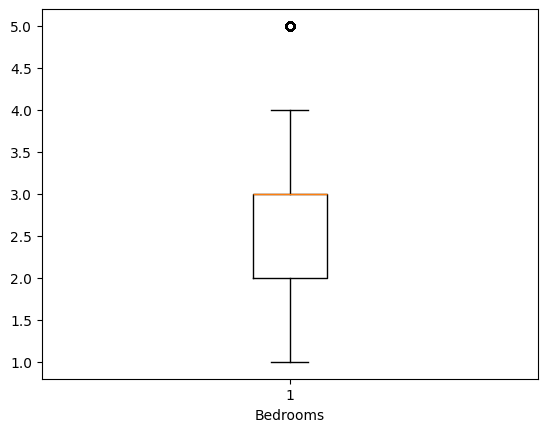

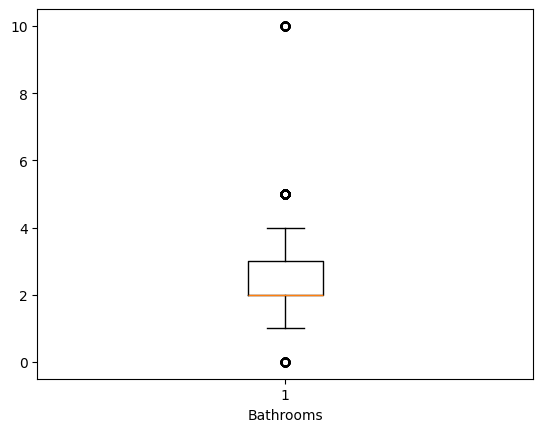

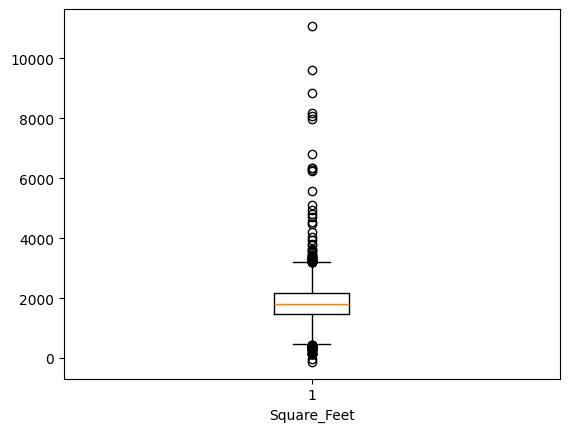

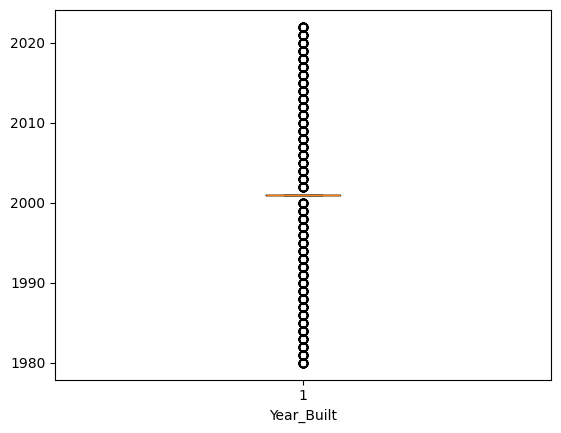

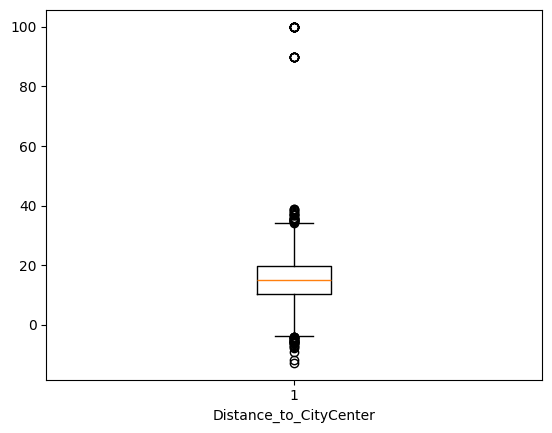

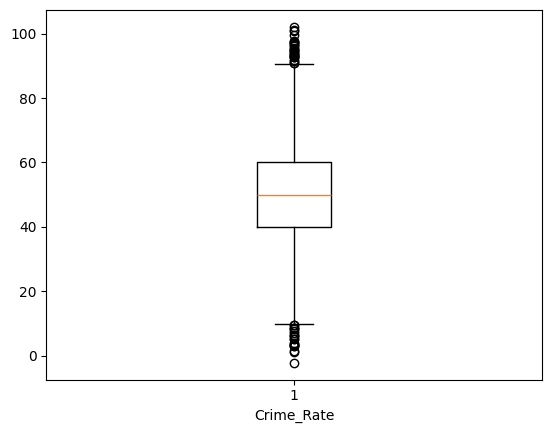

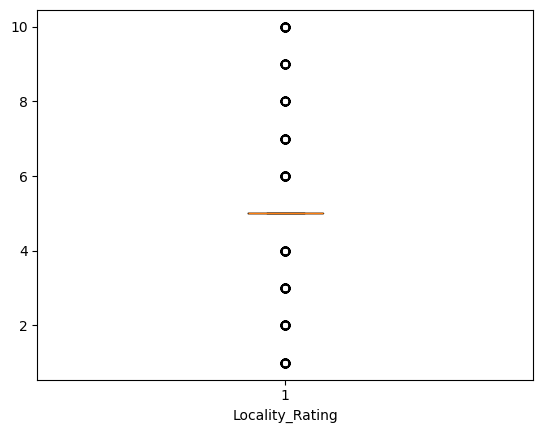

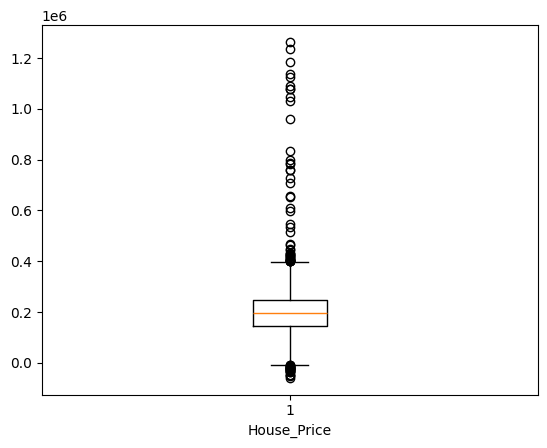

In [ ]:
for i in df.columns:
  if df[i].dtypes != "object":
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

** models like Linear regression are not roboust to outliers i.e; its performance is affected by outliers in the data. so we try to remove outliers**

In [ ]:
# Removing outliers form numeric colums in the data set
for i in df.columns:
  if df[i].dtypes != "object":
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    LB=Q1-1.5*IQR
    UB=Q3+1.5*IQR

    df=df[(df[i]>=LB) & (df[i]<=UB)]

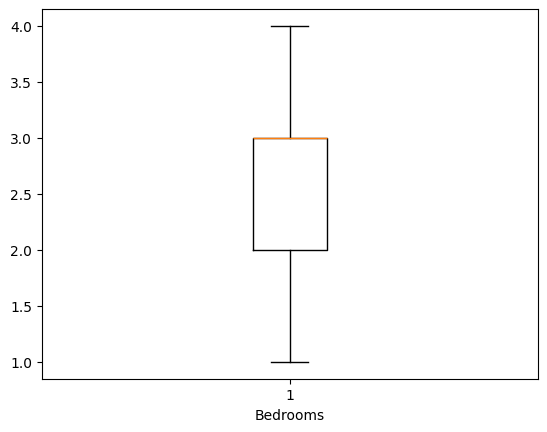

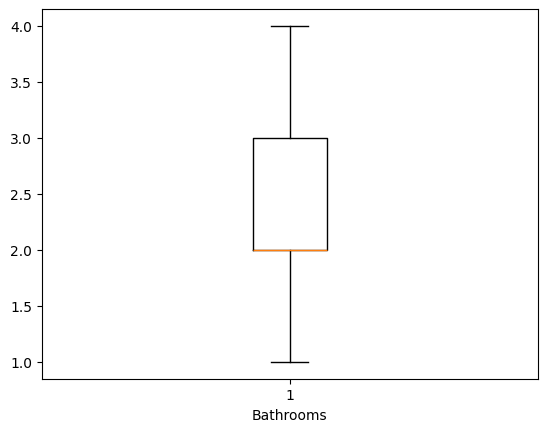

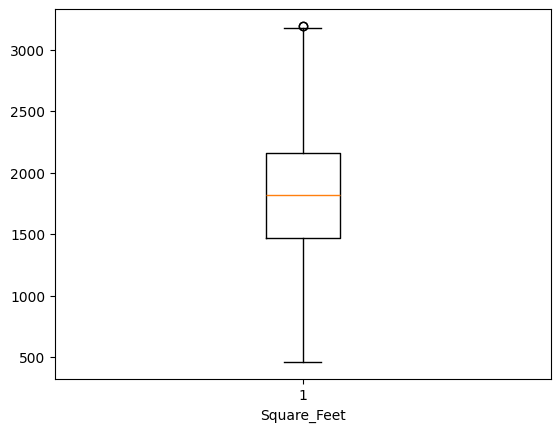

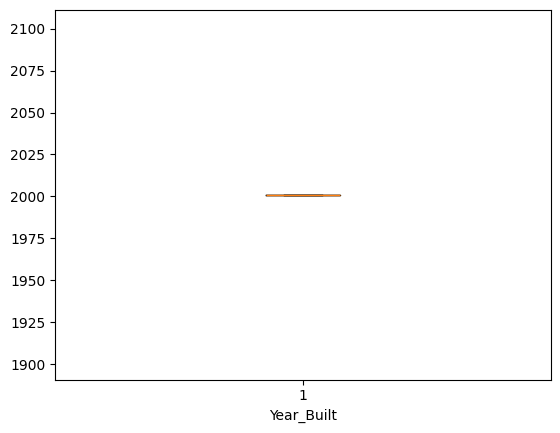

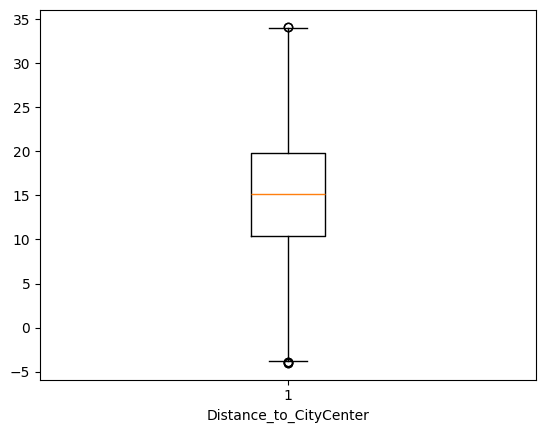

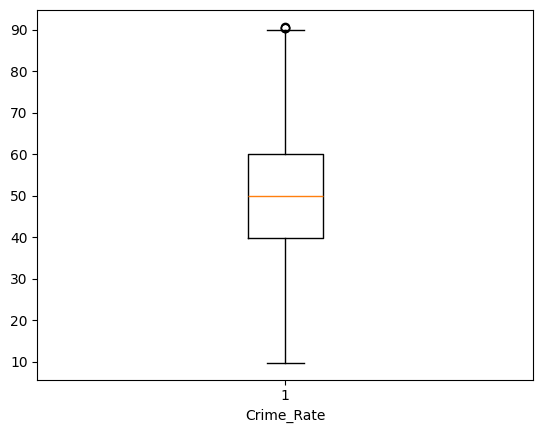

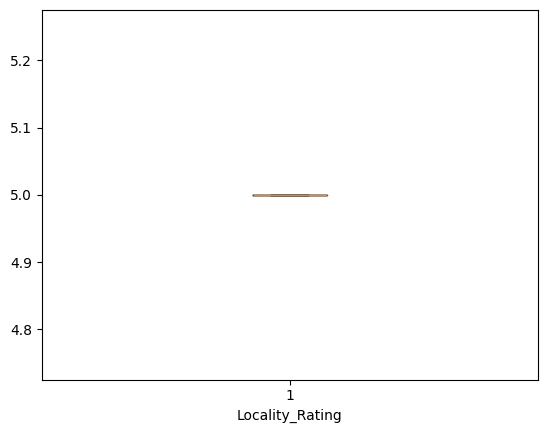

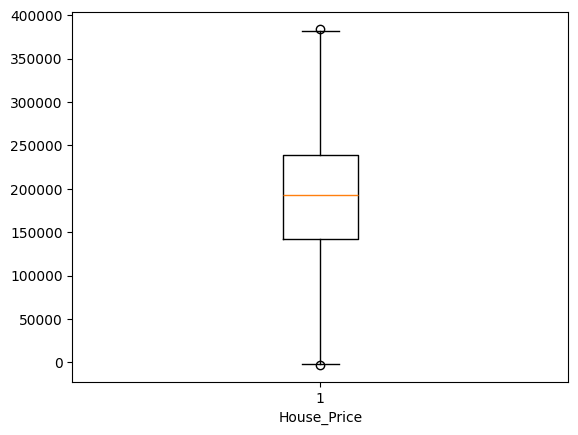

In [ ]:
for i in df.columns:
  if df[i].dtypes != "object":
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
# Making a list of all features i.e; columns
col_features = list(set(df.columns))
col_features

['Bedrooms',
 'Parking',
 'Square_Feet',
 'Distance_to_CityCenter',
 'Area',
 'Bathrooms',
 'Locality_Rating',
 'Furnishing_Status',
 'Year_Built',
 'Crime_Rate',
 'House_Price']

In [ ]:
# dividing features into catogorical and numeric
categorical_features = ['Area','Furnishing_Status','Parking']

In [ ]:
numerical_features = list(set(col_features)-set(categorical_features))
numerical_features

['Bedrooms',
 'Distance_to_CityCenter',
 'Square_Feet',
 'Bathrooms',
 'Locality_Rating',
 'Year_Built',
 'Crime_Rate',
 'House_Price']

# **Catogorical fearures**

**Ploting some graphs and making some insights from the data**

Area
Hilltop            908
Industrial Zone    849
City Outskirts     837
Downtown           837
Uptown             833
Suburb             833
Riverside          829
Name: count, dtype: int64
Area
Hilltop            15.322308
Industrial Zone    14.326696
City Outskirts     14.124198
Downtown           14.124198
Uptown             14.056699
Suburb             14.056699
Riverside          13.989200
Name: proportion, dtype: float64


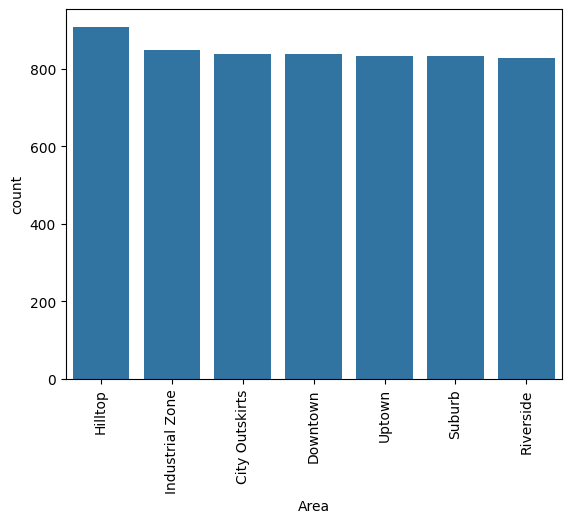

Furnishing_Status
Furnished         1989
Semi-Furnished    1977
Unfurnished       1960
Name: count, dtype: int64
Furnishing_Status
Furnished         33.563955
Semi-Furnished    33.361458
Unfurnished       33.074587
Name: proportion, dtype: float64


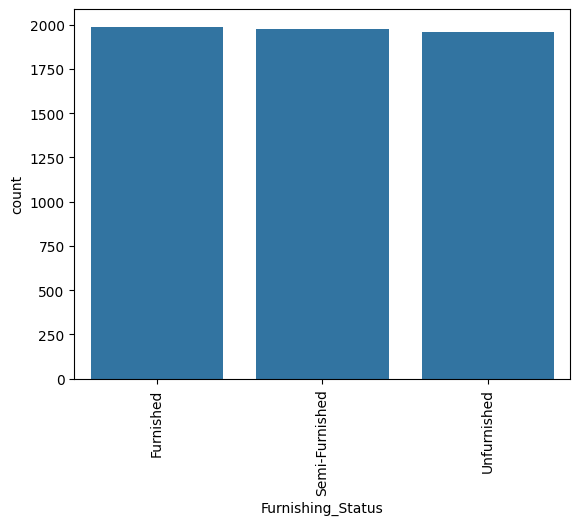

Parking
No     3040
Yes    2886
Name: count, dtype: int64
Parking
No     51.299359
Yes    48.700641
Name: proportion, dtype: float64


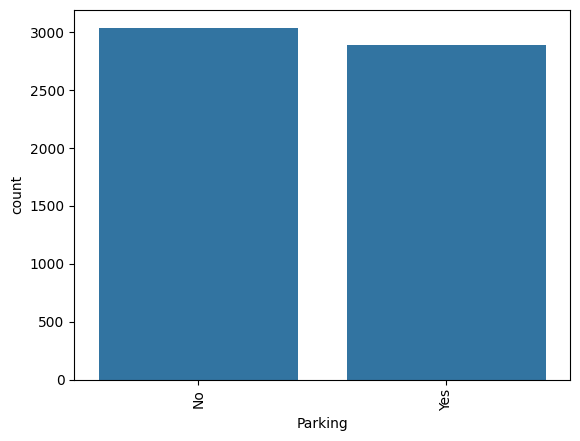

In [ ]:
for feature in categorical_features:
  print(df[feature].value_counts())
  print(df[feature].value_counts(normalize=True)*100)
  sns.barplot(x=df[feature].value_counts().index,y=df[feature].value_counts())
  plt.xlabel(feature)
  plt.xticks(rotation=90)
  plt.show()

- Balanced dataset: Both furnishing status and parking availability are evenly distributed, which is great for predictive modeling (no strong bias).
- Locality importance: Since each area has ~14–15% share, comparisons across areas will be meaningful. Expect location to be a strong driver of house price.
- Furnishing & parking as value-adds: With balanced representation, we can analyze how much extra price furnished homes or homes with parking fetch compared to unfurnished/no-parking ones.
- Hilltop stands out: Slightly more properties are in Hilltop, so it may influence overall averages more than other areas.


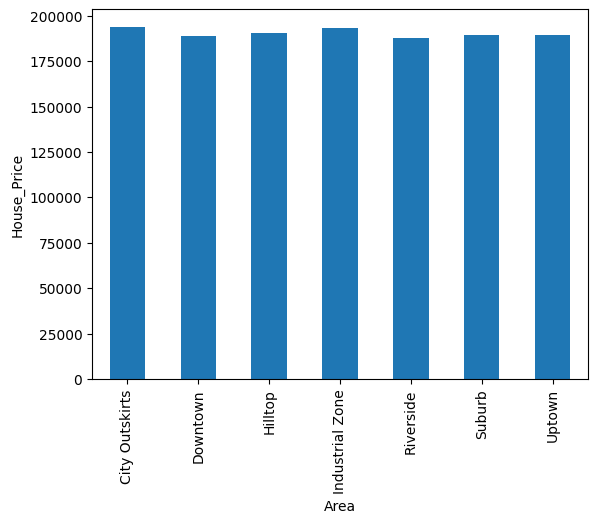

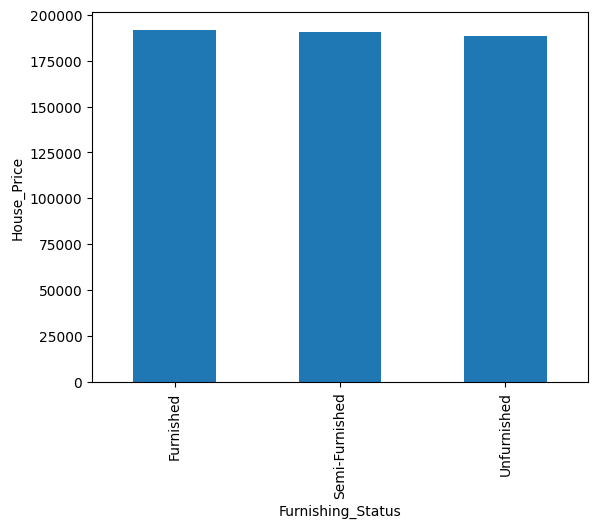

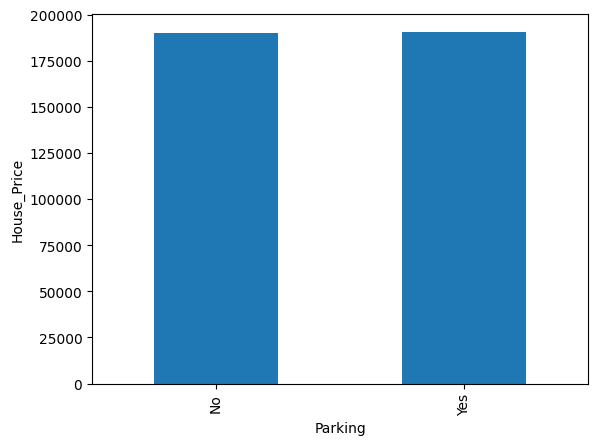

In [ ]:
# bivariate analysis of catogorical data
for feature in categorical_features:
  df.groupby(feature)['House_Price'].mean().plot(kind='bar')
  plt.xlabel(feature)
  plt.ylabel('House_Price')
  plt.show()

    -- The average price for the houses with parking and without parking are almost same, which is good so our data set is not biased but we can't judge just looking upon average

    -- The avereage price of houses with fruniture, semi-furnitured and without furniture is almost the same.

    -- irrelavent of the area (zone) the avg price of the houses are almost same

    -- by just looking t averages we can't say will a feature affect the target colum as avarege can hide variance. so we try to take more insights on diff bases

Area


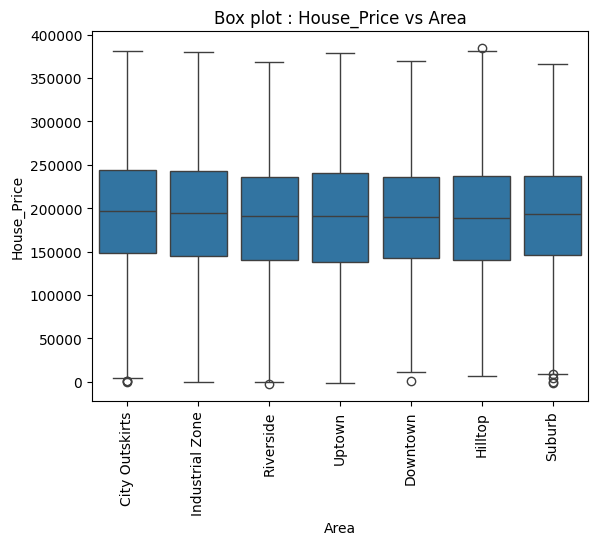

Furnishing_Status


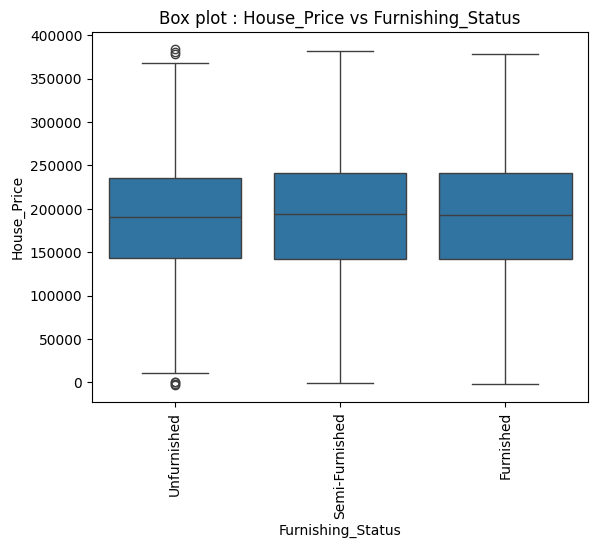

Parking


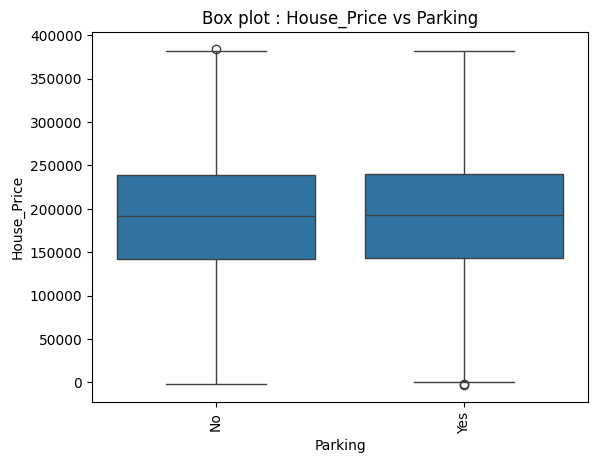

In [ ]:
for feature in categorical_features:
  print(feature)
  plt.title(f'Box plot : House_Price vs {feature}')
  sns.boxplot(x=df[feature],y=df['House_Price'])
  plt.xticks(rotation=90)
  plt.xlabel(feature)
  plt.ylabel('House_Price')
  plt.show()

** Categorical features show balanced distributions and similar averages, meaning they don't strongly explain house price differences. Numerical features should be prioritized for deeper analysis and predictive modeling.**

# **Numerical Features**

Bedrooms


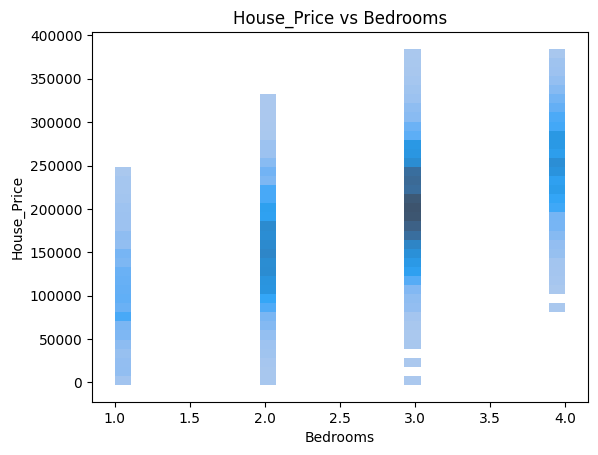

Distance_to_CityCenter


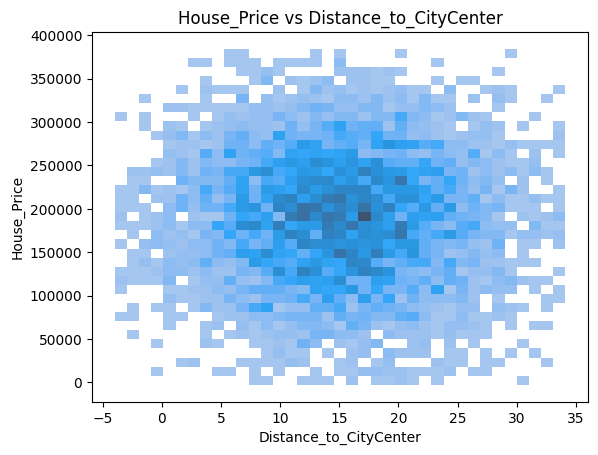

Square_Feet


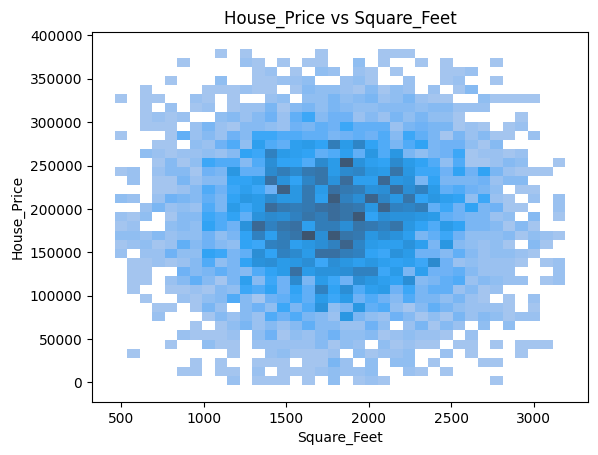

Bathrooms


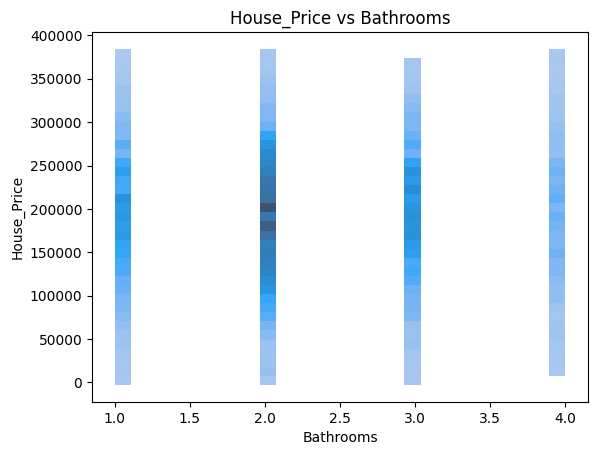

Locality_Rating


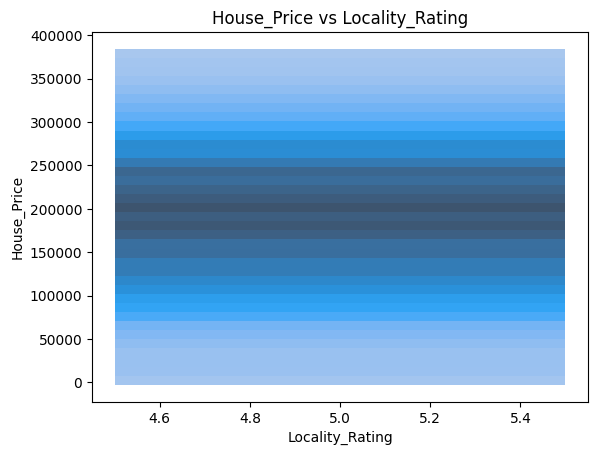

Year_Built


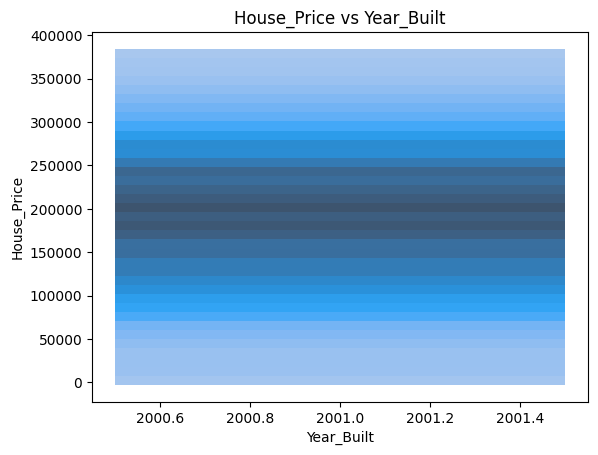

Crime_Rate


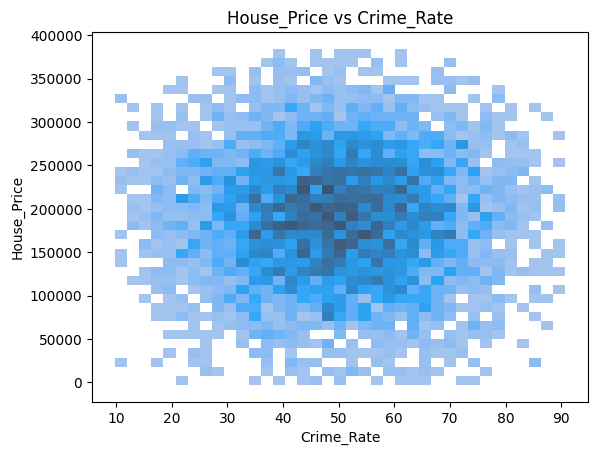

In [ ]:
for feature in numerical_features:
  if feature != 'House_Price':
    print(feature)
    plt.title(f'House_Price vs {feature}')
    sns.histplot(x=df[feature],y=df['House_Price'])
    plt.xlabel(feature)
    plt.ylabel('House_Price')
    plt.show()

*   Safety matters -areas with lower crime may command a premium, but the effect is moderate.
*   Generally the houses which are close to city should have more prize as urban proximity adds value but many houses are clustered at mid-range i.e; 10-20 km from city at a price range of 15L-25L.
*   All the data is equally distributed according to no of bathrooms and by this feature there is not that much impact but it can influence the price by some means.
*   More people prefer a house which is well enough for a family of 6-7 persons (by square feet) but not that big.
*   Year_built and Locality_rating features doesn't have any impact on house price.
*   As the no of bedrooms are increasing we can observe the increase in the range of price of houses.

Bedrooms


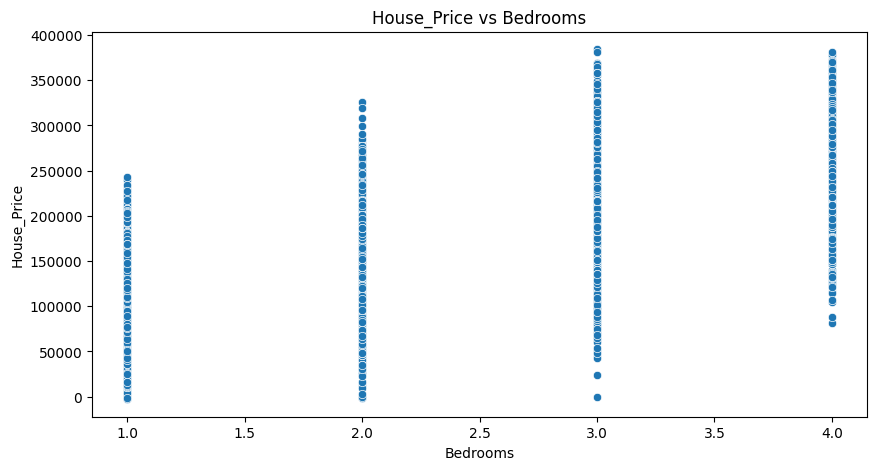

Distance_to_CityCenter


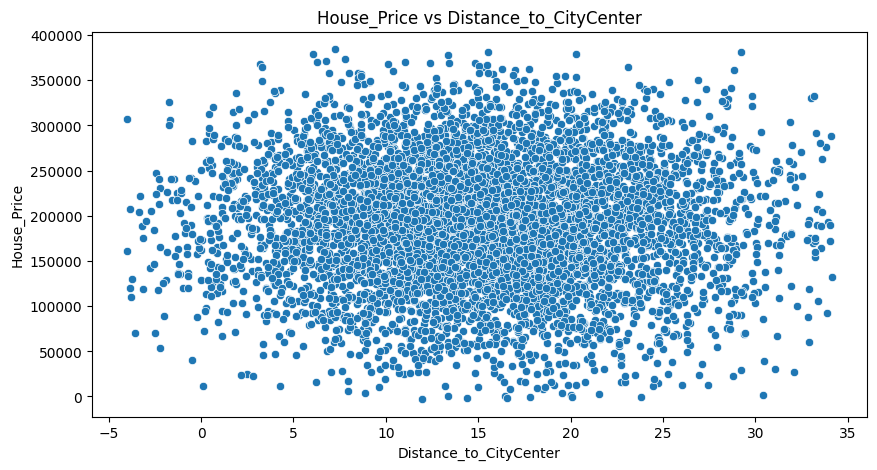

Square_Feet


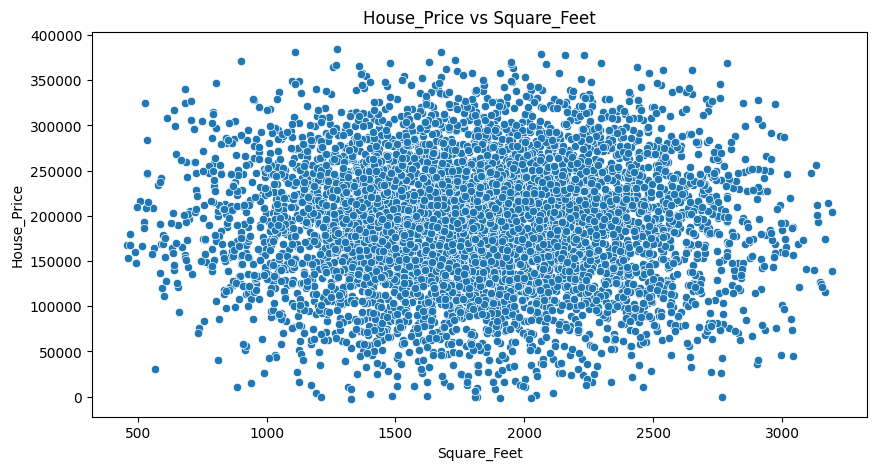

Bathrooms


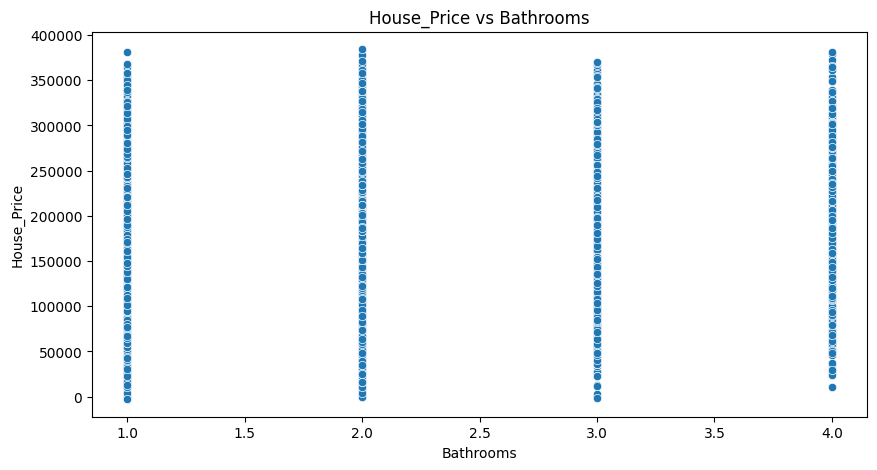

Locality_Rating


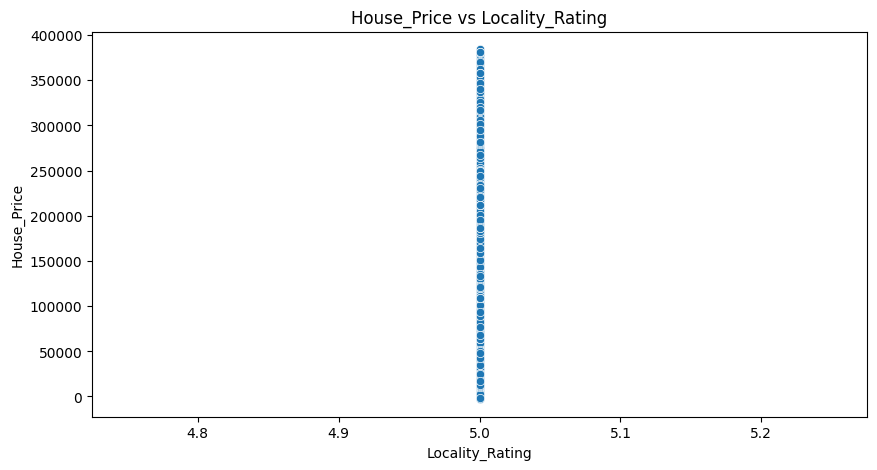

Year_Built


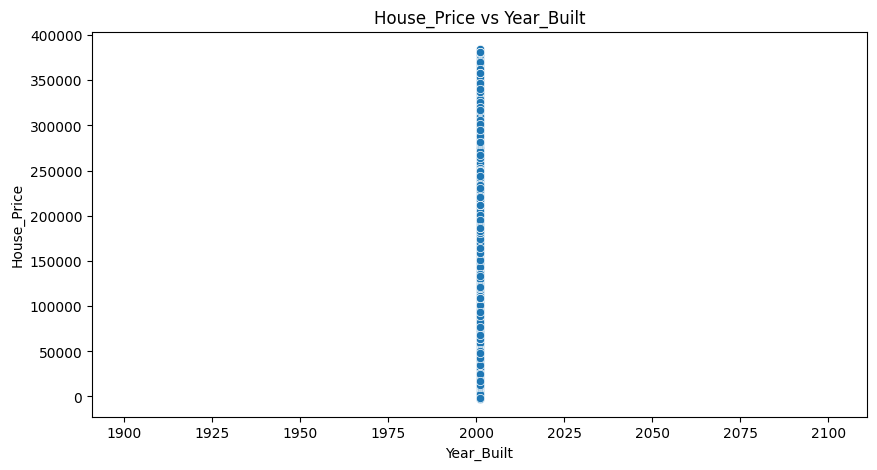

Crime_Rate


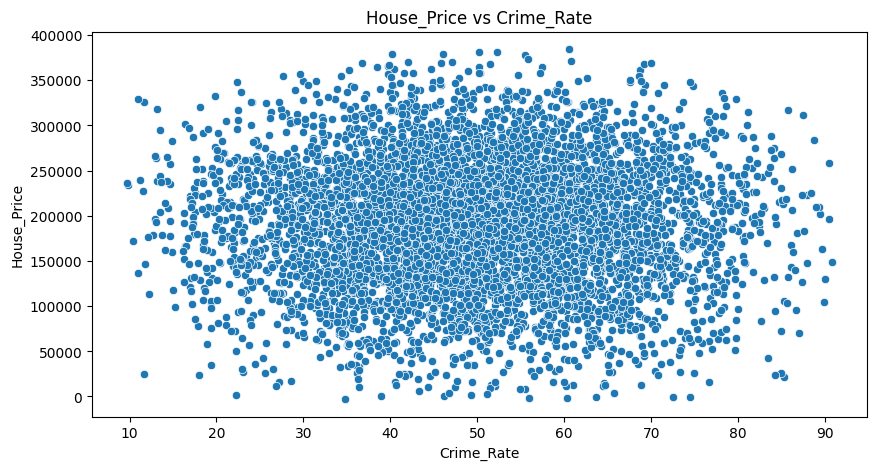

In [ ]:
for feature in numerical_features:
  if feature != 'House_Price':
    print(feature)
    plt.figure(figsize=(10,5))
    plt.title(f'House_Price vs {feature}')
    sns.scatterplot(x= df[feature],y=df['House_Price'])
    plt.xlabel(feature)
    plt.ylabel('House_Price')
    plt.show()

**These graphs also give same insigths as above and one prticular thing that we can observe is that our data is well distrubuteed among the classes in the features**

Bedrooms


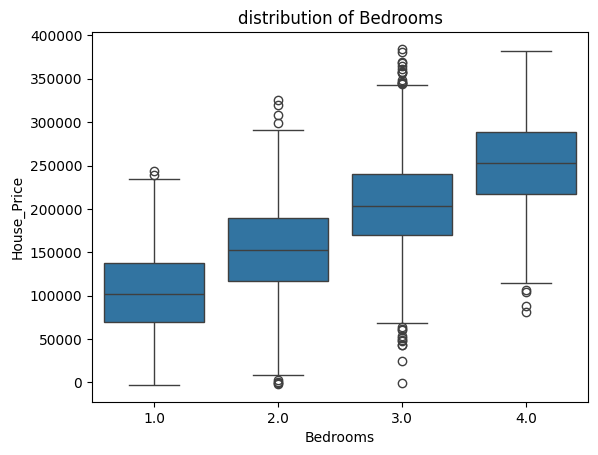

Distance_to_CityCenter


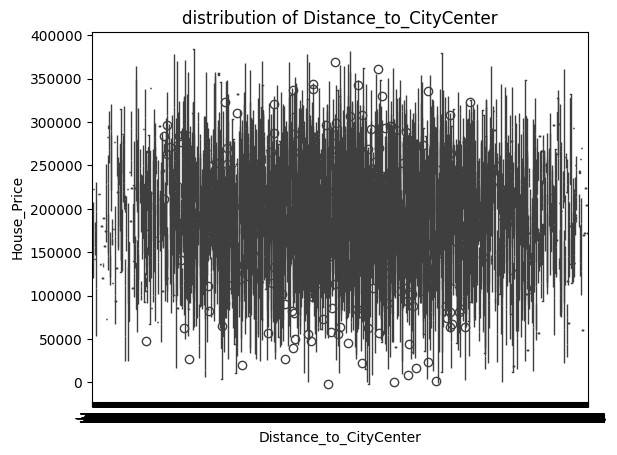

Square_Feet


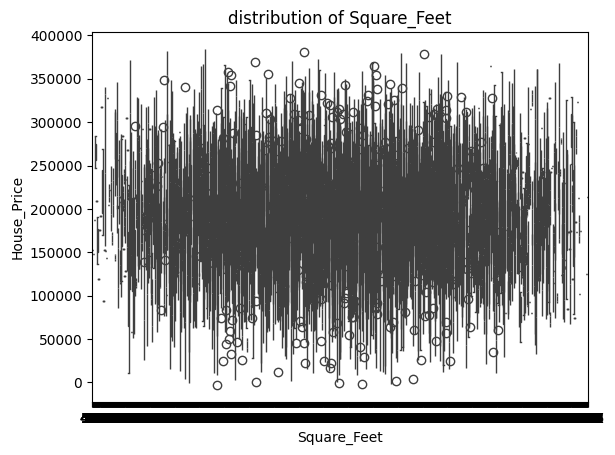

Bathrooms


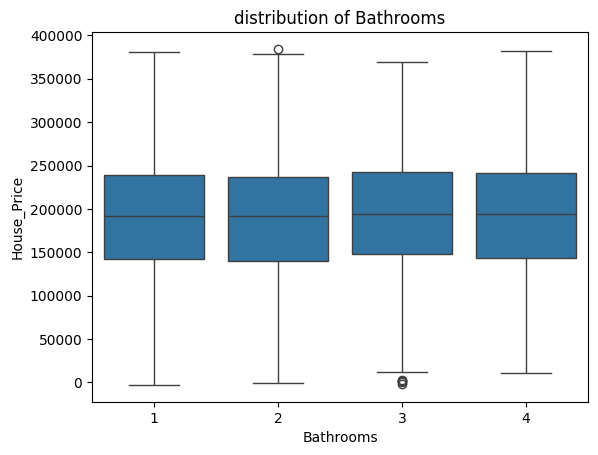

Locality_Rating


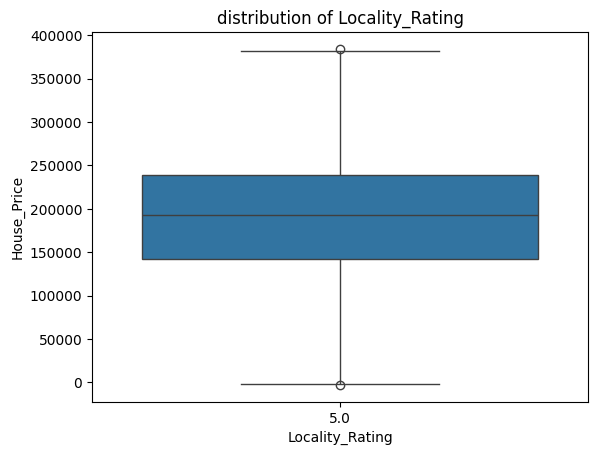

Year_Built


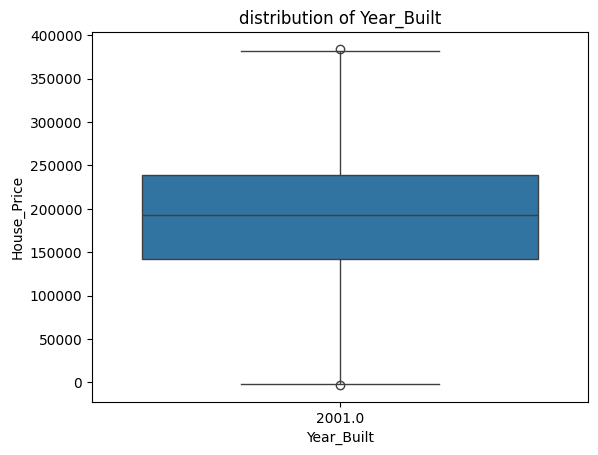

Crime_Rate


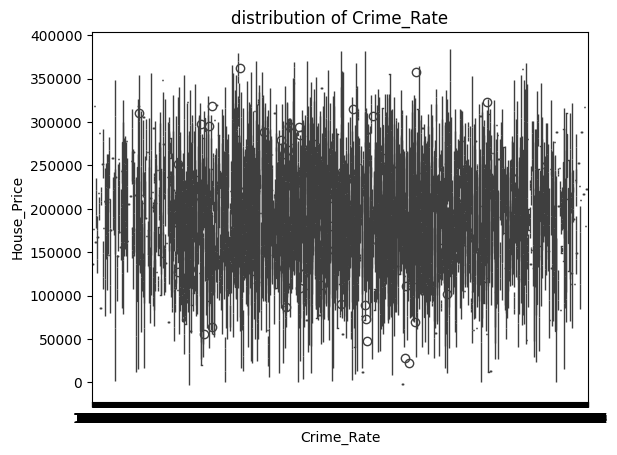

In [ ]:
# bivariant analysis of numeric feature
for feature in numerical_features:
  if feature != 'House_Price':
    print(feature)
    sns.boxplot(x=df[feature],y=df['House_Price'])
    plt.title(f'distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('House_Price')
    plt.show()

<Axes: >

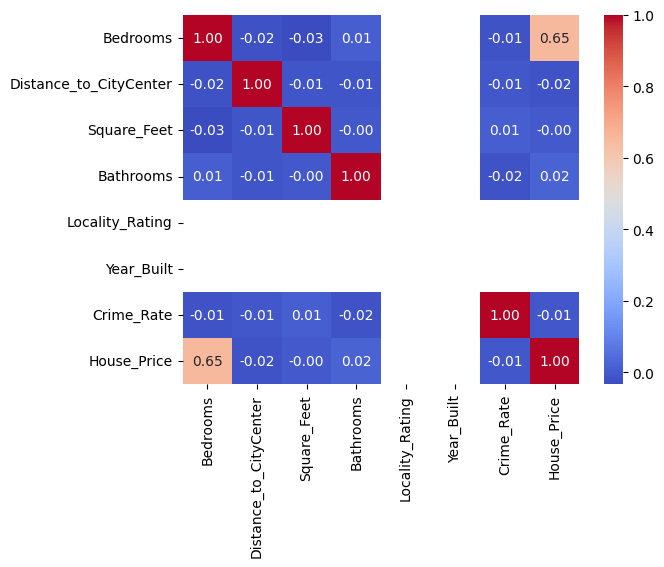

In [ ]:
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm',fmt=".2f")

The feature which affect the house price the most is No.of bedrooms as it hs 65% correlation with hose price

# **Label Encoding**

**As the machine learning models can only uderstand the numerical data and we do have object columns in our data we should encode them to numeric in order to use them.**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtypes == "object":
    df[i]=le.fit_transform(df[i])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5926 entries, 0 to 8034
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    5926 non-null   int64  
 1   Bedrooms                5926 non-null   float64
 2   Bathrooms               5926 non-null   int64  
 3   Square_Feet             5926 non-null   int64  
 4   Parking                 5926 non-null   int64  
 5   Furnishing_Status       5926 non-null   int64  
 6   Year_Built              5926 non-null   float64
 7   Distance_to_CityCenter  5926 non-null   float64
 8   Crime_Rate              5926 non-null   float64
 9   Locality_Rating         5926 non-null   float64
 10  House_Price             5926 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 555.6 KB


In [ ]:
df_copy = df.copy()

# VIF -  Variance Inflation Factor

**By using VIF we can reomove columns which doesn,t give ny information in extra and doesn't affect our predictions**

If VIF score of a column is greater than 5 than we cn drop it(assumption)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes != "object") & (i != "House_Price"):
    col_list.append(i)

x = df[col_list]
vif = pd.DataFrame()
vif["column name"]= x.columns
vif["vif"]= [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,column name,vif
0,Area,1.000689
1,Bedrooms,1.001910
2,Bathrooms,1.000917
3,Square_Feet,1.001378
4,Parking,1.000894
5,Furnishing_Status,1.000680
6,Year_Built,0.000000
7,Distance_to_CityCenter,1.001062
8,Crime_Rate,1.001063
9,Locality_Rating,0.000000


In [ ]:
df = df.drop(['Locality_Rating'],axis=1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes != "object") & (i != "House_Price"):
    col_list.append(i)

x = df[col_list]
vif = pd.DataFrame()
vif["column name"]= x.columns
vif["vif"]= [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif

,column name,vif
0,Area,1.000689
1,Bedrooms,1.001910
2,Bathrooms,1.000917
3,Square_Feet,1.001378
4,Parking,1.000894
5,Furnishing_Status,1.000680
6,Year_Built,53.289212
7,Distance_to_CityCenter,1.001062
8,Crime_Rate,1.001063


In [ ]:
df = df.drop(['Year_Built'],axis=1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes != "object") & (i != "House_Price"):
    col_list.append(i)

x = df[col_list]
vif = pd.DataFrame()
vif["column name"]= x.columns
vif["vif"]= [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif

,column name,vif
0,Area,3.097799
1,Bedrooms,8.072081
2,Bathrooms,6.240248
3,Square_Feet,10.662078
4,Parking,1.915338
5,Furnishing_Status,2.402033
6,Distance_to_CityCenter,5.165017
7,Crime_Rate,9.761371


In [ ]:
df = df.drop(['Square_Feet'],axis=1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes != "object") & (i != "House_Price"):
    col_list.append(i)

x = df[col_list]
vif = pd.DataFrame()
vif["column name"]= x.columns
vif["vif"]= [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif

,column name,vif
0,Area,3.044044
1,Bedrooms,7.537181
2,Bathrooms,5.932981
3,Parking,1.900813
4,Furnishing_Status,2.373517
5,Distance_to_CityCenter,4.965068
6,Crime_Rate,8.573512


In [ ]:
df = df.drop(['Crime_Rate'],axis=1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes != "object") & (i != "House_Price"):
    col_list.append(i)

x = df[col_list]
vif = pd.DataFrame()
vif["column name"]= x.columns
vif["vif"]= [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif

,column name,vif
0,Area,2.952345
1,Bedrooms,6.441595
2,Bathrooms,5.452607
3,Parking,1.885555
4,Furnishing_Status,2.324982
5,Distance_to_CityCenter,4.592642


Even though the VIF score of Bedrooms column is >5 , i didn't drop as it can affect the price as we get to know this from EDA.

**Dividing our data frame into target variable and independent features**

In [ ]:
x=df[['Area','Bathrooms','Parking','Furnishing_Status','Distance_to_CityCenter','Bedrooms']]
y=df['House_Price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=0)

# **Model Building**

Linear Regression

Import the Linear regression model and traning our data and checking it's accuracy(using diff metrices)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
new_df = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
new_df

,Actual,Predicted
6621,272275,204740.808106
7597,204176,107209.337355
1070,219881,156007.227144
4653,254316,250204.930139
7499,203979,203162.123138
...,...,...
5199,146279,149802.969201
7544,65400,157866.221887
4267,22396,105510.432424
2970,161809,201738.414903


In [ ]:
from sklearn.metrics import *

In [ ]:
r2_score(y_test,y_pred)*100

42.46366557309433

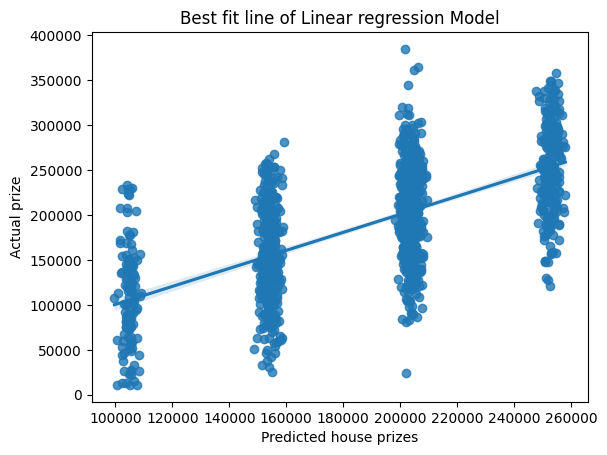

In [ ]:
sns.regplot(x=y_pred,y=y_test)
plt.xlabel('Predicted house prizes')
plt.ylabel('Actual prize')
plt.title('Best fit line of Linear regression Model')
plt.show()

In [ ]:
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 41916.90847513989
Mean Squared Error: 2681971040.1045027
Root Mean Squared Error: 51787.7499038576


SO, our model is expalning 42% variance in our data which is very bad. It is even worse than just taking average of house price as prediction.

As the linear regression is not that effective , lets try diff models and also after trying with diff models let's try to scale the data and try to fit hte data againg in all the models we tried.

Decission treee regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
Dtr = DecisionTreeRegressor()
Dtr.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
y_pred1 = Dtr.predict(x_test)

In [ ]:
pd.DataFrame({"Actual":y_test,"Predicted":y_pred1}).reset_index(drop = True)

,Actual,Predicted
0,272275,275295.0
1,204176,158799.0
2,219881,71166.0
3,254316,306415.0
4,203979,208810.0
...,...,...
1181,146279,88177.0
1182,65400,161557.0
1183,22396,91100.0
1184,161809,215254.0


In [ ]:
r2_score(y_test,y_pred1)*100

-37.77959275965615

In [ ]:
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred1))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred1))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred1)))

Mean Absolute Error: 64111.182546374366
Mean Squared Error: 6422391717.849705
Root Mean Squared Error: 80139.82604080012


Even this model is also not good(Worse)

In [ ]:
depths=[x for x in range(1,11)]
for i in depths:
  model=DecisionTreeRegressor(max_depth=i,random_state=42)
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=r2_score(y_test,y_pred)
  print('Max depth:',i,"r^2 Score",acc)

Max depth: 1 r^2 Score 0.32516791623484875
Max depth: 2 r^2 Score 0.4243521841399076
Max depth: 3 r^2 Score 0.42035559299476444
Max depth: 4 r^2 Score 0.4155443484684861
Max depth: 5 r^2 Score 0.394374817107753
Max depth: 6 r^2 Score 0.3867606254103325
Max depth: 7 r^2 Score 0.36558266075324963
Max depth: 8 r^2 Score 0.34709664767550374
Max depth: 9 r^2 Score 0.3176861198251629
Max depth: 10 r^2 Score 0.3075302921443558


In [ ]:
Dtr.get_depth()

50

**The best r2 score we can get is 42 % which is same as linear regression model. lets try another model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
Rfr = RandomForestRegressor()
Rfr.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
y_pred_rfr = Rfr.predict(x_test)

In [ ]:
pd.DataFrame({"Actual":y_test,"Predicted":y_pred_rfr}).reset_index(drop = True)

,Actual,Predicted
0,272275,222514.620
1,204176,116127.090
2,219881,161878.060
3,254316,255261.856
4,203979,207399.490
...,...,...
1181,146279,119084.540
1182,65400,167253.750
1183,22396,91776.930
1184,161809,215470.870


In [ ]:
r2_score(y_test,y_pred_rfr)*100

29.16708026078022

In [ ]:
n_estimators=[x for x in range(35,80)]
for i in n_estimators:
  temp_model=RandomForestRegressor(n_estimators=i,random_state=23)
  temp_model.fit(x_train,y_train)
  y_pred=temp_model.predict(x_test)
  acc=r2_score(y_test,y_pred)
  print(f'The accuracy for n_estimator {i} is {acc}')

The accuracy for n_estimator 35 is 0.2828897117667887
The accuracy for n_estimator 36 is 0.28442713566844957
The accuracy for n_estimator 37 is 0.28564881501246764
The accuracy for n_estimator 38 is 0.2866802836038399
The accuracy for n_estimator 39 is 0.2869265841238452
The accuracy for n_estimator 40 is 0.2877685647064816
The accuracy for n_estimator 41 is 0.28949895293832806
The accuracy for n_estimator 42 is 0.2896191938376037
The accuracy for n_estimator 43 is 0.2901822448309177
The accuracy for n_estimator 44 is 0.28976097504646947
The accuracy for n_estimator 45 is 0.2909062815358088
The accuracy for n_estimator 46 is 0.29095219585415955
The accuracy for n_estimator 47 is 0.2903921976114624
The accuracy for n_estimator 48 is 0.2896477104434442
The accuracy for n_estimator 49 is 0.29012722914662326
The accuracy for n_estimator 50 is 0.2898584517189732
The accuracy for n_estimator 51 is 0.29045055920559903
The accuracy for n_estimator 52 is 0.29177202579941597
The accuracy for n_e

Using this model also we can only get accuracy upto 30(r2 score)


# Let us scale the data and try the predction

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [ ]:
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [ ]:
Liner_reg = LinearRegression()
Liner_reg.fit(x_train_sc,y_train)

LinearRegression()

In [ ]:
y_pred_sc = Liner_reg.predict(x_test_sc)

In [ ]:
r2_score(y_test,y_pred_sc)*100

42.46366557309431

Decission tree Regressor

In [ ]:
Dtr_sc = DecisionTreeRegressor()
Dtr_sc.fit(x_train_sc,y_train)

DecisionTreeRegressor()

In [ ]:
y_pred_sc1 = Dtr_sc.predict(x_test_sc)

In [ ]:
r2_score(y_test,y_pred_sc1)*100

-40.2202066687513

In [ ]:
depths=[x for x in range(1,11)]
for i in depths:
  model=DecisionTreeRegressor(max_depth=i,random_state=42)
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=r2_score(y_test,y_pred)
  print('Max depth:',i,"r^2 Score",acc)

Max depth: 1 r^2 Score 0.32516791623484875
Max depth: 2 r^2 Score 0.4243521841399076
Max depth: 3 r^2 Score 0.42035559299476444
Max depth: 4 r^2 Score 0.4155443484684861
Max depth: 5 r^2 Score 0.394374817107753
Max depth: 6 r^2 Score 0.3867606254103325
Max depth: 7 r^2 Score 0.36558266075324963
Max depth: 8 r^2 Score 0.34709664767550374
Max depth: 9 r^2 Score 0.3176861198251629
Max depth: 10 r^2 Score 0.3075302921443558


Even after using scaled data we can oly get upto 42% accuracy score

**Random Forest Regressor**

In [ ]:
Rfr_sc = RandomForestRegressor()
Rfr_sc.fit(x_train_sc,y_train)

RandomForestRegressor()

In [ ]:
y_pred_rfr_sc = Rfr_sc.predict(x_test_sc)

In [ ]:
r2_score(y_test,y_pred_rfr_sc)*100

28.75645584461255

# Trying to fit the data set as it is without removing any columns using vif

In [ ]:
x1 = df_copy.drop(['House_Price'],axis=1)
y1 = df_copy['House_Price']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,test_size=0.20,random_state=0)

Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(x1_train,y1_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(x1_test)

In [ ]:
r2_score(y1_test,y_pred_lr)*100

42.49076752598573

Random forest regressor

In [ ]:
Rfr1 = RandomForestRegressor()
Rfr1.fit(x1_train,y1_train)

RandomForestRegressor()

In [ ]:
Rfr1_pred = Rfr1.predict(x1_test)

In [ ]:
r2_score(y1_test,Rfr1_pred)*100

38.66082109906613

In [ ]:
n_estimators=[x for x in range(35,80)]
for i in n_estimators:
  temp_model=RandomForestRegressor(n_estimators=i,random_state=23)
  temp_model.fit(x1_train,y1_train)
  y_pred=temp_model.predict(x1_test)
  acc=r2_score(y_test,y_pred)
  print(f'The accuracy for n_estimator {i} is {acc}')

The accuracy for n_estimator 35 is 0.37829944995002174
The accuracy for n_estimator 36 is 0.3780509057019168
The accuracy for n_estimator 37 is 0.37797043849318823
The accuracy for n_estimator 38 is 0.37866779823596575
The accuracy for n_estimator 39 is 0.3801325534069039
The accuracy for n_estimator 40 is 0.3800216076087398
The accuracy for n_estimator 41 is 0.37861744474771863
The accuracy for n_estimator 42 is 0.3785492634472132
The accuracy for n_estimator 43 is 0.3796391904377622
The accuracy for n_estimator 44 is 0.38112721345362544
The accuracy for n_estimator 45 is 0.382375258079348
The accuracy for n_estimator 46 is 0.38263089737397005
The accuracy for n_estimator 47 is 0.3818338562950244
The accuracy for n_estimator 48 is 0.38285099206173223
The accuracy for n_estimator 49 is 0.3828479000690942
The accuracy for n_estimator 50 is 0.3822714929618264
The accuracy for n_estimator 51 is 0.38113772669572876
The accuracy for n_estimator 52 is 0.3807106036572109
The accuracy for n_es

In [ ]:
dtr1 = DecisionTreeRegressor()
dtr1.fit(x1_train,y1_train)

DecisionTreeRegressor()

In [ ]:
dtr1_pred = dtr1.predict(x1_test)

In [ ]:
r2_score(y1_test,dtr1_pred)*100

-24.99621031888022

In [ ]:
dtr1.get_depth()

46

In [ ]:
depths=[x for x in range(1,11)]
for i in depths:
  model=DecisionTreeRegressor(max_depth=i,random_state=42)
  model.fit(x1_train,y1_train)
  y_pred=model.predict(x1_test)
  acc=r2_score(y_test,y_pred)
  print('Max depth:',i,"r^2 Score",acc)

Max depth: 1 r^2 Score 0.32516791623484875
Max depth: 2 r^2 Score 0.4243521841399076
Max depth: 3 r^2 Score 0.42384937538942846
Max depth: 4 r^2 Score 0.414440231489692
Max depth: 5 r^2 Score 0.40482763014086387
Max depth: 6 r^2 Score 0.39082928982710863
Max depth: 7 r^2 Score 0.3757597600930188
Max depth: 8 r^2 Score 0.3571180282048404
Max depth: 9 r^2 Score 0.35033920898408166
Max depth: 10 r^2 Score 0.30452168642278044


**So,by looking at the above results I can conclude that we are able to explain more variance in the data without using the VIF but even these results are not that good**

so after using all models we can conclude that we can't use these models to predict the house prices as they are very bad

The reasons for this maybe are variance in our data set or the data is not enough.